In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import PchipInterpolator

from pathlib import Path

In [3]:
RAW_DATA_DIR = Path("data/raw")

files = {
    'DGS1MO.csv': ('1M', 1/12),
    'DGS3MO.csv': ('3M', 3/12),
    'DGS6MO.csv': ('6M', 6/12),
    'DGS1.csv':   ('1Y', 1),
    'DGS2.csv':   ('2Y', 2),
    'DGS3.csv':   ('3Y', 3),
    'DGS5.csv':   ('5Y', 5)
}

dfs = []
for f_name, (label, maturity) in files.items():
    file_path = RAW_DATA_DIR / f_name
    
    df = pd.read_csv(file_path, parse_dates=['observation_date'], na_values='.')
    df = df.rename(columns={'observation_date': 'date', df.columns[1]: 'yield'})
    df['yield'] = pd.to_numeric(df['yield']) / 100
    
    df = df.set_index('date').sort_index()
    df = df.ffill()
    
    dfs.append(df['yield'].rename(label))

df_yields = pd.concat(dfs, axis=1).dropna()
maturities = np.array(list(files.values()))

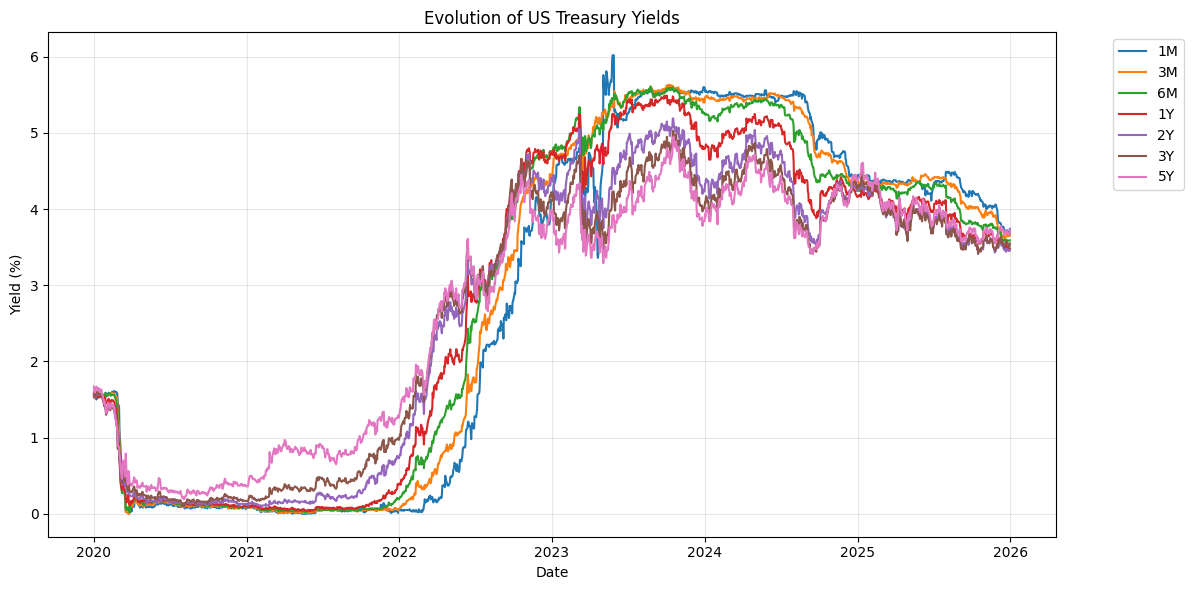

In [4]:
plt.figure(figsize=(12, 6))
for col in df_yields.columns:
    plt.plot(df_yields.index, df_yields[col] * 100, label=col)

plt.title("Evolution of US Treasury Yields")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("yield_time_series.png")
plt.show()

In [5]:
maturities

array([['1M', '0.08333333333333333'],
       ['3M', '0.25'],
       ['6M', '0.5'],
       ['1Y', '1'],
       ['2Y', '2'],
       ['3Y', '3'],
       ['5Y', '5']], dtype='<U32')

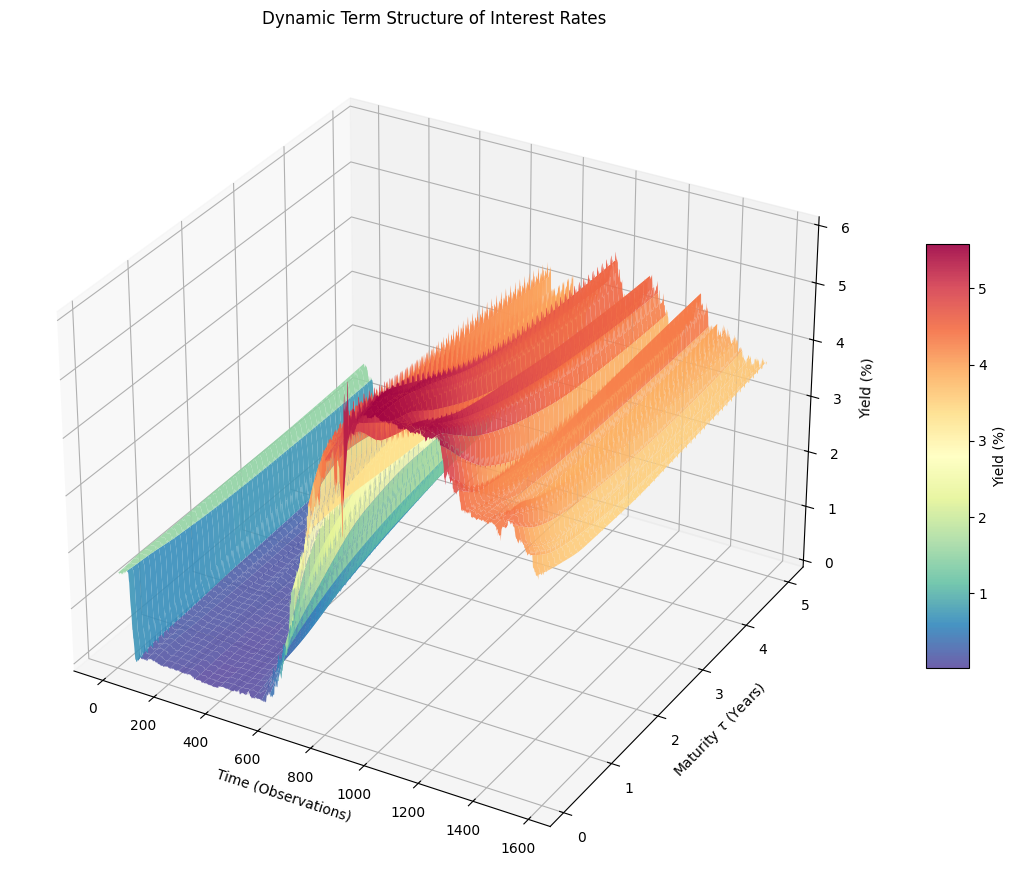

In [6]:
maturities = np.array([v[1] for v in files.values()])

tau_grid = np.linspace(maturities.min(), maturities.max(), 50)
surface_z = []

for i in range(len(df_yields)):
    y = df_yields.iloc[i].values
    interp = PchipInterpolator(maturities, y, extrapolate=True)
    surface_z.append(interp(tau_grid))

surface_z = np.array(surface_z)

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(np.arange(len(df_yields)), tau_grid)
Z = surface_z.T 

surf = ax.plot_surface(X, Y, Z * 100, cmap='Spectral_r', edgecolor='none', alpha=0.9)

ax.set_title("Dynamic Term Structure of Interest Rates")
ax.set_xlabel("Time (Observations)")
ax.set_ylabel("Maturity $\\tau$ (Years)")
ax.set_zlabel("Yield (%)")

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Yield (%)')
ax.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.show()

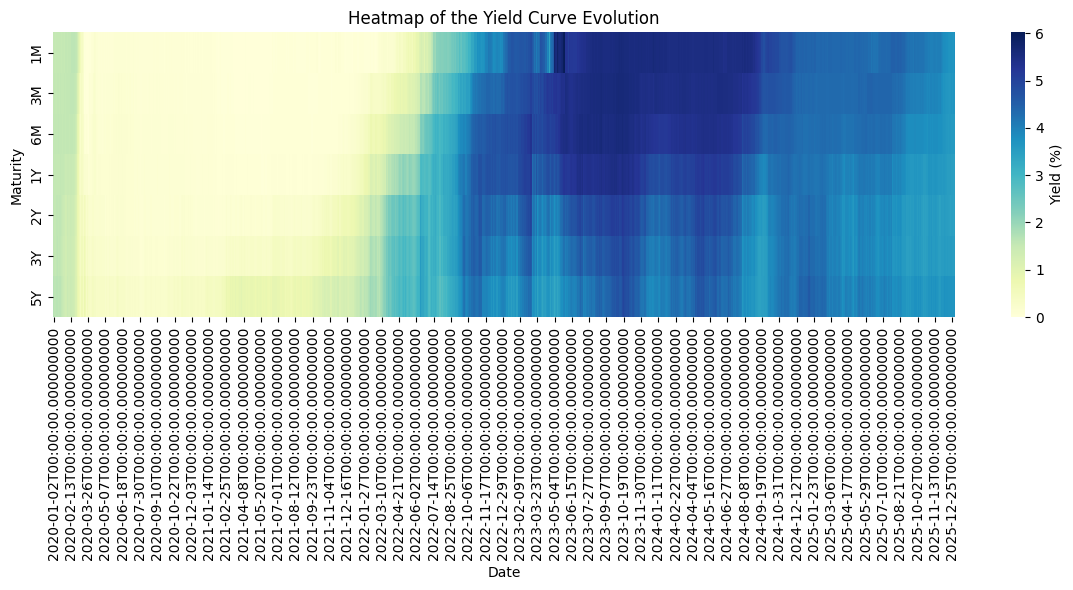

In [7]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_yields.T * 100, cmap="YlGnBu", cbar_kws={'label': 'Yield (%)'})
plt.title("Heatmap of the Yield Curve Evolution")
plt.xlabel("Date")
plt.ylabel("Maturity")
plt.tight_layout()
plt.savefig("yield_heatmap.png")

In [8]:
df_yields.head(20)

,1M,3M,6M,1Y,2Y,3Y,5Y
date,,,,,,,
2020-01-02,0.0153,0.0154,0.0157,0.0156,0.0158,0.0159,0.0167
2020-01-03,0.0152,0.0152,0.0155,0.0155,0.0153,0.0154,0.0159
2020-01-06,0.0154,0.0156,0.0156,0.0154,0.0154,0.0156,0.0161
2020-01-07,0.0152,0.0154,0.0156,0.0153,0.0154,0.0155,0.0162
2020-01-08,0.0150,0.0154,0.0156,0.0155,0.0158,0.0161,0.0167
2020-01-09,0.0153,0.0154,0.0156,0.0154,0.0158,0.0159,0.0165
2020-01-10,0.0152,0.0154,0.0155,0.0153,0.0156,0.0159,0.0163
2020-01-13,0.0154,0.0157,0.0157,0.0153,0.0158,0.0160,0.0165
2020-01-14,0.0153,0.0157,0.0157,0.0153,0.0158,0.0159,0.0163


In [9]:
maturities

array([0.08333333, 0.25      , 0.5       , 1.        , 2.        ,
       3.        , 5.        ])

In [10]:
def get_r_cont_row(row):
    date = pd.to_datetime(row['quote_datetime'])
    T = row['tau']
    
    y = df_yields.loc[date].values.astype(float)
    
    interp = PchipInterpolator(maturities, y, extrapolate=True)
    yT = float(interp(T))
    
    r_cont = np.log(1 + yT)
    return r_cont

In [12]:
RAW_DATA_DIR = Path("data/raw")
PARQUET_FILE = RAW_DATA_DIR / "options_surfaces_data.parquet"

df = pl.read_parquet(PARQUET_FILE, use_pyarrow=True, memory_map=True)

In [19]:
with open(PARQUET_FILE, "rb") as f:
    f.seek(0)
    first_bytes = f.read(4)
    f.seek(-4, 2)
    last_bytes = f.read(4)

print(f"First octets : {first_bytes}") # Should be b'PAR1'
print(f"Last octets : {last_bytes}")  # Should be b'PAR1'

First octets : b'PAR1'
Last octets : b'PAR1'


In [20]:
df

underlying_symbol,quote_datetime,expiration,strike,option_type,implied_volatility,delta,bid_size,bid,ask_size,ask,underlying_bid,underlying_ask,trade_volume,open_interest
str,str,datetime[μs],f64,str,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,200.0,"""C""",0.0,0.9708,15,97.55,15,99.2,298.4,298.42,0,64
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,200.0,"""P""",2.186,-0.0005,0,0.0,72,0.01,298.4,298.42,0,1345
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,205.0,"""C""",0.0,0.969,74,92.5,74,94.2,298.4,298.42,0,2
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,205.0,"""P""",2.0591,-0.0006,0,0.0,63,0.01,298.4,298.42,0,63
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,210.0,"""C""",0.0,0.966,53,87.5,53,89.25,298.4,298.42,0,6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""V""","""2025-12-29 12:00:00""",2028-12-15 16:00:00,500.0,"""P""",0.2465,-0.8443,21,143.0,2,148.0,354.29,354.35,0,0
"""V""","""2025-12-29 12:00:00""",2028-12-15 16:00:00,510.0,"""C""",0.2196,0.3013,17,19.05,37,21.95,354.29,354.35,0,0
"""V""","""2025-12-29 12:00:00""",2028-12-15 16:00:00,510.0,"""P""",0.256,-0.8477,2,153.0,2,158.0,354.29,354.35,0,0


In [21]:
df.schema

Schema([('underlying_symbol', String),
        ('quote_datetime', String),
        ('expiration', Datetime(time_unit='us', time_zone=None)),
        ('strike', Float64),
        ('option_type', String),
        ('implied_volatility', Float64),
        ('delta', Float64),
        ('bid_size', Int64),
        ('bid', Float64),
        ('ask_size', Int64),
        ('ask', Float64),
        ('underlying_bid', Float64),
        ('underlying_ask', Float64),
        ('trade_volume', Int64),
        ('open_interest', Int64)])

In [22]:
INDEX_ETFS = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

df = df.with_columns([
    pl.col("expiration").str.to_datetime().dt.truncate("1d").alias("expiry_base")
]).with_columns([
    pl.when(pl.col("underlying_symbol").is_in(INDEX_ETFS))
    .then(pl.col("expiry_base") + pl.duration(hours=16, minutes=15))
    .otherwise(pl.col("expiry_base") + pl.duration(hours=16))
    .alias("expiration")
]).drop("expiry_base")

print(df.select(["underlying_symbol", "expiration"]).unique(subset="underlying_symbol").head(14))

SchemaError: invalid series dtype: expected `String`, got `datetime[μs]` for series with name `expiration`

In [23]:
df

underlying_symbol,quote_datetime,expiration,strike,option_type,implied_volatility,delta,bid_size,bid,ask_size,ask,underlying_bid,underlying_ask,trade_volume,open_interest
str,str,datetime[μs],f64,str,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,200.0,"""C""",0.0,0.9708,15,97.55,15,99.2,298.4,298.42,0,64
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,200.0,"""P""",2.186,-0.0005,0,0.0,72,0.01,298.4,298.42,0,1345
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,205.0,"""C""",0.0,0.969,74,92.5,74,94.2,298.4,298.42,0,2
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,205.0,"""P""",2.0591,-0.0006,0,0.0,63,0.01,298.4,298.42,0,63
"""AAPL""","""2020-01-02 12:00:00""",2020-01-03 16:00:00,210.0,"""C""",0.0,0.966,53,87.5,53,89.25,298.4,298.42,0,6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""V""","""2025-12-29 12:00:00""",2028-12-15 16:00:00,500.0,"""P""",0.2465,-0.8443,21,143.0,2,148.0,354.29,354.35,0,0
"""V""","""2025-12-29 12:00:00""",2028-12-15 16:00:00,510.0,"""C""",0.2196,0.3013,17,19.05,37,21.95,354.29,354.35,0,0
"""V""","""2025-12-29 12:00:00""",2028-12-15 16:00:00,510.0,"""P""",0.256,-0.8477,2,153.0,2,158.0,354.29,354.35,0,0


In [24]:
df = df.with_columns([
    pl.col("quote_datetime").str.to_datetime()
]).with_columns([
    (
        (pl.col("expiration") - pl.col("quote_datetime")).dt.total_seconds() 
        / (365.25 * 24 * 3600)
    )
    .cast(pl.Float64)
    .alias("tau")
])

df = df.filter(pl.col("tau") > 0)

print(df.select(["underlying_symbol", "expiration", "quote_datetime", "tau"]).head())

shape: (5, 4)
┌───────────────────┬─────────────────────┬─────────────────────┬──────────┐
│ underlying_symbol ┆ expiration          ┆ quote_datetime      ┆ tau      │
│ ---               ┆ ---                 ┆ ---                 ┆ ---      │
│ str               ┆ datetime[μs]        ┆ datetime[μs]        ┆ f64      │
╞═══════════════════╪═════════════════════╪═════════════════════╪══════════╡
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
│ AAPL              ┆ 2020-01-03 16:00:00 ┆ 2020-01-02 12:00:00 ┆ 0.003194 │
└───────────────────┴─────────────────────┴─────────────────────┴──────────┘


In [25]:
pdf = df.select(["quote_datetime", "tau"]).to_pandas()

In [26]:
pdf

,quote_datetime,tau
0,2020-01-02 12:00:00,0.003194
1,2020-01-02 12:00:00,0.003194
2,2020-01-02 12:00:00,0.003194
3,2020-01-02 12:00:00,0.003194
4,2020-01-02 12:00:00,0.003194
...,...,...
83335200,2025-12-29 12:00:00,2.962811
83335201,2025-12-29 12:00:00,2.962811
83335202,2025-12-29 12:00:00,2.962811
83335203,2025-12-29 12:00:00,2.962811


In [27]:
def apply_rate(pdf, df_yields, maturities):
    pdf['date_only'] = pd.to_datetime(pdf['quote_datetime']).dt.normalize()
    df_yields.index = pd.to_datetime(df_yields.index).normalize()

    rate_results = np.empty(len(pdf))

    for date, group_indices in pdf.groupby('date_only').groups.items():
        idx = df_yields.index.get_indexer([date], method='pad')[0]
        if idx == -1: continue
        
        y_curve = df_yields.iloc[idx].values.astype(float)
        
        taus = pdf.loc[group_indices, 'tau'].values
        
        interp = PchipInterpolator(maturities, y_curve, extrapolate=True)
        y_interpolated = interp(taus)
        
        rate_results[group_indices] = np.log(1 + y_interpolated)
        
    return rate_results

pdf["rate"] = apply_rate(pdf, df_yields, maturities)

In [28]:
rate_series = pl.Series("rate", pdf["rate"].values)
df = df.with_columns(rate_series)

In [29]:
df.head(10)

underlying_symbol,quote_datetime,expiration,strike,option_type,implied_volatility,delta,bid_size,bid,ask_size,ask,underlying_bid,underlying_ask,trade_volume,open_interest,tau,rate
str,datetime[μs],datetime[μs],f64,str,f64,f64,i64,f64,i64,f64,f64,f64,i64,i64,f64,f64
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,200.0,"""C""",0.0,0.9708,15,97.55,15,99.2,298.4,298.42,0,64,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,200.0,"""P""",2.186,-0.0005,0,0.0,72,0.01,298.4,298.42,0,1345,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,205.0,"""C""",0.0,0.969,74,92.5,74,94.2,298.4,298.42,0,2,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,205.0,"""P""",2.0591,-0.0006,0,0.0,63,0.01,298.4,298.42,0,63,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,210.0,"""C""",0.0,0.966,53,87.5,53,89.25,298.4,298.42,0,6,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,210.0,"""P""",1.9349,-0.0006,0,0.0,59,0.01,298.4,298.42,0,361,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,215.0,"""C""",0.0,0.9938,15,83.25,20,83.5,298.4,298.42,0,21,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,215.0,"""P""",1.8132,-0.0006,0,0.0,38,0.01,298.4,298.42,0,297,0.003194,0.015168
"""AAPL""",2020-01-02 12:00:00,2020-01-03 16:00:00,220.0,"""C""",0.0,0.9934,50,78.25,23,78.5,298.4,298.42,0,76,0.003194,0.015168


In [30]:
PROCESSED_DATA_DIR = Path("data/processed")
OUTPUT_FILE = PROCESSED_DATA_DIR / "options_surfaces_data.parquet"

df.write_parquet(OUTPUT_FILE, compression="zstd")